
#Customer Lifetime Value (CLV) Prediction System
---


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb

%matplotlib inline

Load & Preview Dataset

In [39]:
df = pd.read_csv("file.csv")

# Drop rows with missing customer or transaction ID
df.dropna(subset=["CustomerID", "Transaction_ID", "Transaction_Date"], inplace=True)

# Convert dates
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])
df["Date"] = pd.to_datetime(df["Date"], errors='coerce')

# Calculate Revenue
df["Revenue"] = df["Quantity"] * df["Avg_Price"]

# Total Spend
df["Total_Spend"] = df["Offline_Spend"] + df["Online_Spend"]

df.head()

,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct,Revenue,Total_Spend
0,0,17850.0,M,Chicago,12.0,16679.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,Used,0.1,2019-01-01,4500.0,2424.5,1,ELEC10,10.0,153.71,6924.5
1,1,17850.0,M,Chicago,12.0,16680.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,Used,0.1,2019-01-01,4500.0,2424.5,1,ELEC10,10.0,153.71,6924.5
2,2,17850.0,M,Chicago,12.0,16696.0,2019-01-01,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,...,Not Used,0.1,2019-01-01,4500.0,2424.5,1,ELEC10,10.0,245.54,6924.5
3,3,17850.0,M,Chicago,12.0,16699.0,2019-01-01,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,...,Clicked,0.1,2019-01-01,4500.0,2424.5,1,ELEC10,10.0,81.50,6924.5
4,4,17850.0,M,Chicago,12.0,16700.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,Clicked,0.1,2019-01-01,4500.0,2424.5,1,ELEC10,10.0,153.71,6924.5


#Exploratory Data Analysis (EDA) & Hypotheses

### Hypotheses:
1. Customers with recent purchases will have higher CLV.
2. Average Order Value (AOV) will differ across industries.
3. Customers using mobile may have higher churn.
4. Lifecycle stage influences revenue potential.

In [40]:
hypotheses = [
    "Customers with longer tenure spend more.",
    "Male and female customers have different CLV values.",
    "Use of coupons increases overall customer value.",
    "Online spenders have a higher repeat rate than offline spenders."
]
for h in hypotheses:
    print("- " + h)

- Customers with longer tenure spend more.
- Male and female customers have different CLV values.
- Use of coupons increases overall customer value.
- Online spenders have a higher repeat rate than offline spenders.



## Feature Engineering
- **Recency**: Days since last purchase
- **Frequency**: Number of transactions
- **Monetary**: Total value spent
- **Tenure**: Days since signup
- **AOV**: Average order value
- **Age Group** and **Lifecycle Stage Encoding**


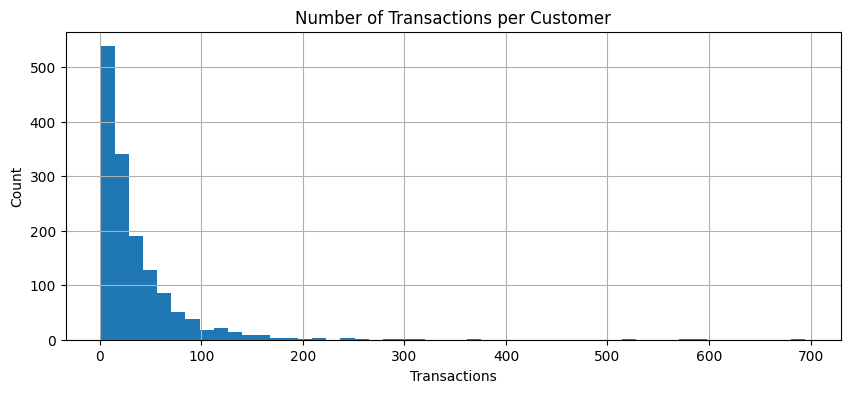

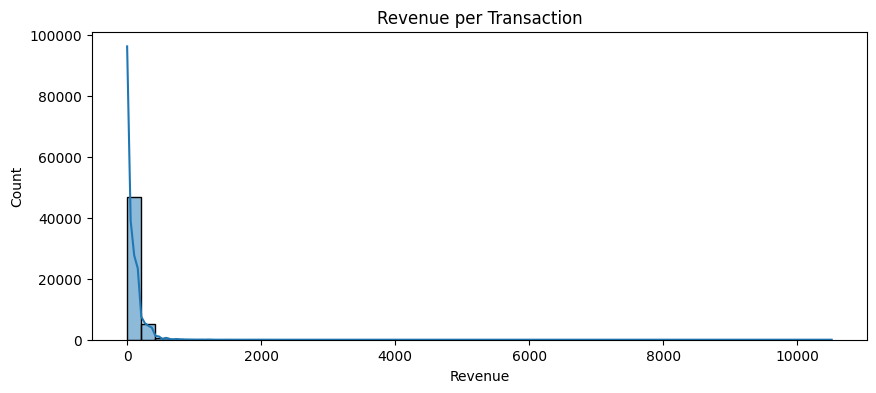

In [41]:
# Frequency of transactions per customer
plt.figure(figsize=(10,4))
df['CustomerID'].value_counts().hist(bins=50)
plt.title("Number of Transactions per Customer")
plt.xlabel("Transactions")
plt.ylabel("Count")
plt.show()

# Revenue distribution
plt.figure(figsize=(10,4))
sns.histplot(df["Revenue"], bins=50, kde=True)
plt.title("Revenue per Transaction")
plt.show()


##Probabilistic CLV Estimation using BG/NBD + Gamma-Gamma
- Expected number of future transactions per customer
- Expected average value per transaction
- Then calculate basic predicted CLV

In [42]:
clv_data = summary_data_from_transaction_data(df, 'CustomerID', 'Transaction_Date', 
                                               monetary_value_col='Revenue', observation_period_end=df['Transaction_Date'].max())

# Fit BG/NBD
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(clv_data['frequency'], clv_data['recency'], clv_data['T'])

# Predict expected purchases
clv_data['pred_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30, clv_data['frequency'], clv_data['recency'], clv_data['T'])

# Gamma-Gamma
ggf = GammaGammaFitter(penalizer_coef=0.01)
# Filter out rows with non-positive monetary values
clv_data = clv_data[clv_data['monetary_value'] > 0]

# Fit Gamma-Gamma model
ggf.fit(clv_data['frequency'], clv_data['monetary_value'])

# Predict expected average profit
clv_data['pred_value'] = ggf.conditional_expected_average_profit(clv_data['frequency'], clv_data['monetary_value'])

# CLV calculation
clv_data['clv'] = ggf.customer_lifetime_value(bgf, clv_data['frequency'], clv_data['recency'],
                                              clv_data['T'], clv_data['monetary_value'], time=1, freq='D', discount_rate=0.01)

clv_data.head()

c:\Users\aufaa\finale\finale_venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,frequency,recency,T,monetary_value,pred_purchases,pred_value,clv
CustomerID,,,,,,,
12347.0,2.0,223.0,282.0,1309.425000,0.172513,1492.308284,254.893117
12348.0,1.0,119.0,192.0,665.090000,0.100633,882.634193,87.943011
12370.0,1.0,30.0,219.0,635.300000,0.044790,843.275381,37.396080
12377.0,1.0,139.0,179.0,6545.830000,0.117057,8652.319938,1002.786182
12383.0,3.0,72.0,171.0,745.476667,0.258712,812.290833,208.068817


In [43]:
# Merge back CLV
df = df.merge(clv_data[['clv']], left_on='CustomerID', right_index=True, how='inner')

# Define features and target
features = ['Tenure_Months', 'Quantity', 'Avg_Price', 'Discount_pct', 'GST', 'Online_Spend', 'Offline_Spend']
X = df[features]
y = df['clv']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"XGBoost RMSE: {rmse:.2f}")

XGBoost RMSE: 342.41



## XGBoost Modeling + SHAP + CLV Segmentation
- Train XGBoost using RFM + probabilistic CLV features
- Tune hyperparameters (GridSearch)
- Use SHAP to find most important features
- Remove low-impact features
- Predict refined CLV
- Segment customers into High, Medium, Low tiers


In [44]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# Target: probabilistic CLV
X = rfm.drop(columns=['customer_id', 'probabilistic_clv'])
y = rfm['probabilistic_clv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Basic XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid Search for hyperparameter tuning
param_grid = {
    'max_depth': [3, 4, 5],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
}
grid = GridSearchCV(xgb_model, param_grid, cv=3, scoring='neg_mean_absolute_error', verbose=1)
print(grid)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# Predict
y_pred = best_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")


NameError: name 'rfm' is not defined

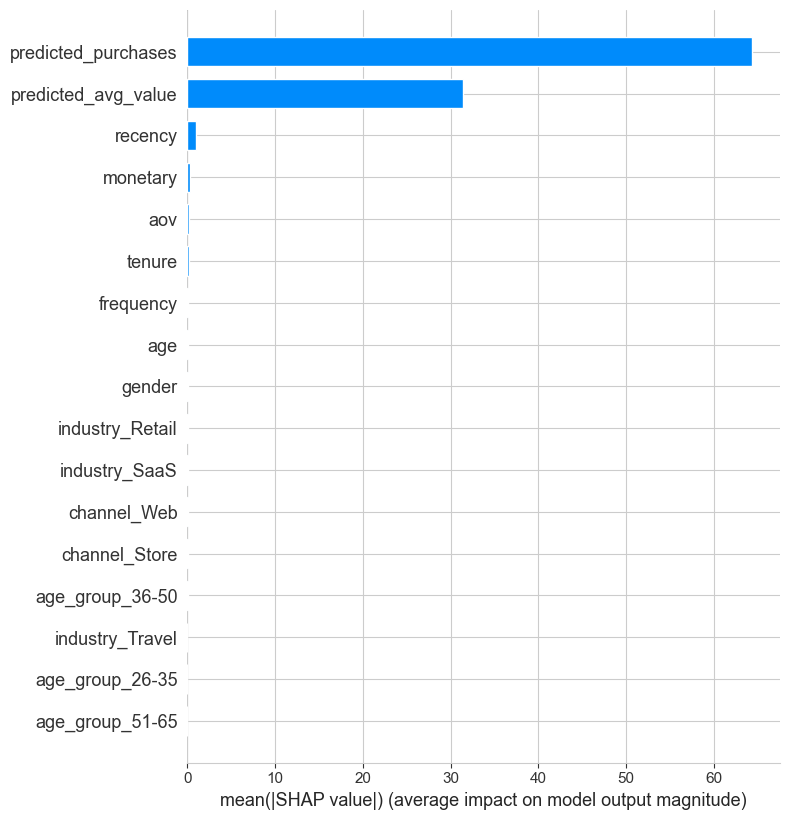

In [ ]:

import shap

explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)

# Plot summary
shap.summary_plot(shap_values, X_train, plot_type="bar")


In [ ]:


# Final predictions on entire dataset
rfm['predicted_clv'] = best_model.predict(X)

# Segment customers
quantiles = rfm['predicted_clv'].quantile([0.33, 0.66]).values
def segment_clv(clv):
    if clv <= quantiles[0]:
        return 'Low'
    elif clv <= quantiles[1]:
        return 'Medium'
    else:
        return 'High'

rfm['clv_segment'] = rfm['predicted_clv'].apply(segment_clv)

rfm[['customer_id', 'predicted_clv', 'clv_segment']].head()


,customer_id,predicted_clv,clv_segment
0,1,327.812561,High
1,2,41.118156,Medium
2,3,16.923323,Low
3,4,4.582825,Low
4,5,15.196515,Low


In [ ]:

# Export full data
rfm.to_csv("final_customer_clv_segments.csv", index=False)

# Export VIPs and churn risk segments
vip_customers = rfm[rfm['clv_segment'] == 'High'].sort_values(by='predicted_clv', ascending=False).head(100)
churn_risk = rfm[rfm['predicted_purchases'] < 1]

vip_customers.to_csv("top_100_vips.csv", index=False)
churn_risk.to_csv("churn_risk_customers.csv", index=False)
